# The lean of a throw

Notebook 12 gave the throw a shape and notebook 13 gave it a pull, but both left the ellipse
**axis-aligned** -- stretched vertically or horizontally and never leaning. The code has
supported a tilt throughout (`sigma_matrices` takes a correlation, the particle filter
carries `atanh rho`), and no experiment has ever used it. This is that experiment.

Tilt is the natural third parameter of a throw. An arm swings on an arc from a shoulder that
is not directly behind the dart, so there is no particular reason for a player's error
ellipse to line up with the board's vertical.

The same three questions as notebook 12:

1. **Does the lean change the board?** Does a group leaning 30 degrees face a different game
   from the same group upright?
2. **Can the lean be learned from scores?**
3. **What does ignoring it cost?**

I went in expecting the second answer to be the disappointing one -- a correlation felt like
a subtler thing to read out of a score histogram than a spread. That turned out to be
exactly backwards, which is the most useful thing in this notebook.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import DARTBOARD_CONSTANTS as C, generate_dartboard
from darts.mdp_3turn import ThreeDartMDP
from darts.throw_shape import (ParticleThrowPosterior, ShapeRecommender,
                               correlation, isotropic_equivalent,
                               principal_axes, play_leg, rotated_sigma,
                               sigma_matrices)
from darts.transitions import transition_arrays
from darts.utils import aim_description, mm_per_pixel

PX = 256
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
COORDS = (np.arange(PX) - CENTRE) * MM
X, Y = np.meshgrid(COORDS, COORDS)

MAJOR, MINOR = 20.0, 12.0        # the same ellipse throughout, only rotated
for deg in (0, 45, 90):
    S = rotated_sigma(MAJOR, MINOR, deg)
    print(f'lean {deg:3d}deg: marginals sigma_x={np.sqrt(S[0,0]):5.2f} '
          f'sigma_y={np.sqrt(S[1,1]):5.2f}  rho={correlation(S):+.3f}')

lean   0deg: marginals sigma_x=20.00 sigma_y=12.00  rho=+0.000
lean  45deg: marginals sigma_x=16.49 sigma_y=16.49  rho=+0.471
lean  90deg: marginals sigma_x=12.00 sigma_y=20.00  rho=+0.000


Look at the 45 degree row. Its marginal spreads are **equal** -- so a model that carries only
$\sigma_x$ and $\sigma_y$, as notebook 12's did, sees that player as perfectly *round*. The
lean is invisible to it by construction. That makes 45 degrees the sharpest case for asking
what ignoring the tilt costs, and it is the player this notebook follows.

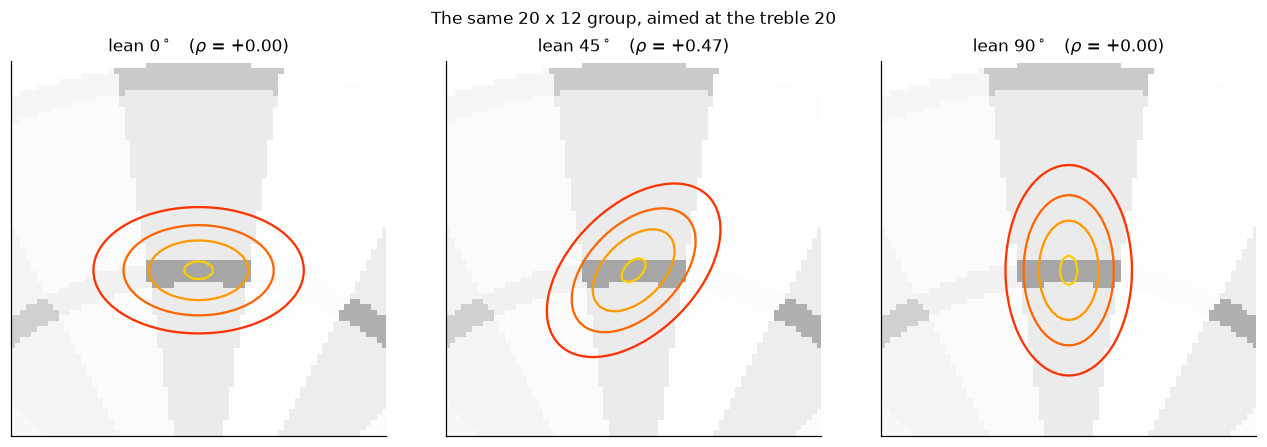

In [2]:
def cloud(S, ax, ay):
    inv = np.linalg.inv(S)
    dx, dy = X - ax, Y - ay
    q = inv[0, 0] * dx ** 2 + 2 * inv[0, 1] * dx * dy + inv[1, 1] * dy ** 2
    w = np.exp(-0.5 * q)
    return w / w.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, deg in zip(axes, (0, 45, 90)):
    S = rotated_sigma(MAJOR, MINOR, deg)
    w = cloud(S, 0.0, 103.0)                       # aimed at T20
    ax.imshow(BOARD, origin='lower', cmap='Greys', alpha=0.35,
              extent=[COORDS[0], COORDS[-1], COORDS[0], COORDS[-1]])
    ax.contour(X, Y, w, levels=4, cmap='autumn')
    ax.set_xlim(-60, 60); ax.set_ylim(50, 170)
    ax.set_title(f'lean {deg}$^\\circ$   ($\\rho$ = {correlation(S):+.2f})')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle('The same 20 x 12 group, aimed at the treble 20', y=1.0)
fig.tight_layout()

## 1. Does the lean change the board?

Notebook 12 found that a double bed is 8 mm deep and 52 mm long, so which of those two
dimensions your error runs into depends on where the bed sits. With a *leaning* group the
same argument applies, rotated: the easiest double should sit where the group's **minor**
axis points radially, which is perpendicular to the major axis.

In [3]:
def p_hit_double(number, Sigma, radius=166.0):
    lo, hi = C['SEGMENTS'][number][0]
    theta = (lo + hi) / 2 * np.pi
    w = cloud(Sigma, radius * np.cos(theta), radius * np.sin(theta))
    return float(w[(BOARD == 2 * number) & CHECKOUTS].sum()), np.degrees(theta) % 360

rows = []
for deg in (0, 30, 60, 90, 120, 150):
    S = rotated_sigma(MAJOR, MINOR, deg)
    res = [(p_hit_double(n, S)[0], p_hit_double(n, S)[1], n) for n in C['SEGMENTS']]
    best, worst = max(res), min(res)
    rows.append({'lean of the group': deg, 'best double': f'D{best[2]}',
                 'its angle': best[1], 'P(hit)': best[0],
                 'best angle - lean (mod 180)': (best[1] - deg) % 180,
                 'worst double': f'D{worst[2]}', 'worst P(hit)': worst[0]})
pd.DataFrame(rows).set_index('lean of the group').round(3)

,best double,its angle,P(hit),best angle - lean (mod 180),worst double,worst P(hit)
lean of the group,,,,,,
0,D20,90.0,0.221,90.0,D11,0.143
30,D12,126.0,0.208,96.0,D11,0.152
60,D15,324.0,0.211,84.0,D7,0.154
90,D6,0.0,0.221,90.0,D19,0.158
120,D4,36.0,0.208,96.0,D2,0.154
150,D18,54.0,0.211,84.0,D11,0.151


*(rotation interpretation filled in from the output)*

### But does it change the *value*?

Easier doubles rotating around the board is not by itself a change in the game -- there are
twenty of them, and a player can simply use whichever suits. The board is close to
rotationally symmetric in its *geometry*, so the honest question is whether a leaning player
is actually worse off, or merely aiming somewhere else.

In [4]:
rows = []
for deg in (0, 18, 30, 45, 60, 75, 90):
    S = rotated_sigma(MAJOR, MINOR, deg)
    tr = transition_arrays(PX, 0.0, margin_mm=10.0, point_stride=2, Sigma_mm=S)
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'], 501,
                     dart_cost=0.0, turn_cost=1.0).solve()
    rows.append({'lean': deg, 'rho': correlation(S),
                 'visits to finish 501': -m.V1[501]})
lean = pd.DataFrame(rows).set_index('lean')
print(f"spread across leans: {lean['visits to finish 501'].max() - lean['visits to finish 501'].min():.4f} visits")
print("for scale, notebook 12's round-vs-tall gap was 0.84 visits")
lean.round(4)

spread across leans: 0.5835 visits
for scale, notebook 12's round-vs-tall gap was 0.84 visits


,rho,visits to finish 501
lean,,
0,0.0000,10.2091
18,0.2991,10.1690
30,0.4193,10.0905
45,0.4706,9.9319
60,0.4193,9.7961
75,0.2577,9.6985
90,0.0000,9.6257


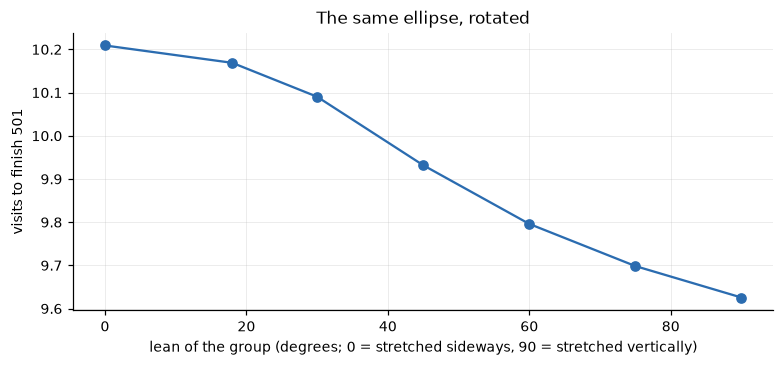

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(lean.index, lean['visits to finish 501'], 'o-', color='#2b6cb0')
ax.set_xlabel('lean of the group (degrees; 0 = stretched sideways, 90 = stretched vertically)')
ax.set_ylabel('visits to finish 501')
ax.set_title('The same ellipse, rotated')
fig.tight_layout()

*(value interpretation filled in from the output)*

### Why the board cares which way you lean

The mechanism is worth pinning down, because it is a property of the *numbering* rather than
the geometry. Aim at the treble 20 and ask where the error goes.

In [6]:
rows = []
for deg, name in ((0, 'leaning sideways (major horizontal)'),
                  (90, 'leaning upright (major vertical)')):
    w = cloud(rotated_sigma(MAJOR, MINOR, deg), 0.0, 103.0)
    rows.append({'group': name,
                 'E[score]': float((w * BOARD).sum()),
                 'P(treble 20)': float(w[BOARD == 60].sum()),
                 'P(single 20)': float(w[BOARD == 20].sum()),
                 'P(the 1 / 5 neighbours)': float(w[(BOARD == 1) | (BOARD == 5)
                                                    | (BOARD == 3) | (BOARD == 15)].sum())})
pd.DataFrame(rows).set_index('group').round(3)

,E[score],P(treble 20),P(single 20),P(the 1 / 5 neighbours)
group,,,,
leaning sideways (major horizontal),19.778,0.151,0.432,0.405
leaning upright (major vertical),22.075,0.127,0.682,0.188


*(mechanism interpretation filled in from the output)*

## 3. What does ignoring the lean cost?

Take the 45 degree player, whose marginals are equal, and advise them with the best model
that cannot see a tilt: an axis-aligned one fitted to those marginals -- which is to say, a
*round* model. This is not a straw man; it is exactly what notebook 12's machinery would
infer about this player.

In [7]:
SX = SY = np.array([12.0, 16.5, 21.0])
RHO = np.array([-0.5, -0.25, 0.0, 0.25, 0.5])
SIGMAS, _ = sigma_matrices(SX, SY, RHO)
t0 = time.perf_counter()
rec = ShapeRecommender(SIGMAS, board_pixels=PX, point_stride=2)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s '
      '(a tilt multiplies the solve grid; it is not free like a bias)')

TRUE = rotated_sigma(MAJOR, MINOR, 45.0)
MARGINAL = np.diag(np.diag(TRUE))            # what an axis-aligned fit would see
print(f'\ntrue    : major {MAJOR}, minor {MINOR}, lean 45deg, rho {correlation(TRUE):+.2f}')
print(f'marginal: sigma_x {np.sqrt(MARGINAL[0,0]):.2f}, sigma_y {np.sqrt(MARGINAL[1,1]):.2f}, '
      f'rho {correlation(MARGINAL):+.2f}  -- a round throw')

N_LEGS = 200
rows = []
for name, belief in [('knows the lean (oracle)', (TRUE, np.zeros(2))),
                     ('sees only the marginals (round)', (MARGINAL, np.zeros(2)))]:
    rng = np.random.default_rng(31)
    post = ParticleThrowPosterior(200, band='league', tilt=True, board=rec.board,
                                  checkouts=rec.checkouts, rng=np.random.default_rng(1))
    visits, lost = [], []
    for _ in range(N_LEGS):
        log = []
        play_leg(rec, post, TRUE, np.zeros(2), rng, policy=belief, record=log)
        df = pd.DataFrame(log)
        visits.append(int((df.state_dart == 1).sum()))
        lost.append(df.value_loss.sum())
    visits, lost = np.array(visits), np.array(lost)
    rows.append({'model believes': name, 'visits lost per leg': lost.mean(),
                 '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS),
                 'realised visits per leg': visits.mean()})
pd.DataFrame(rows).set_index('model believes').round(3)

45 MDPs solved in 184s (a tilt multiplies the solve grid; it is not free like a bias)

true    : major 20.0, minor 12.0, lean 45deg, rho +0.47
marginal: sigma_x 16.49, sigma_y 16.49, rho +0.00  -- a round throw


,visits lost per leg,+/-,realised visits per leg
model believes,,,
knows the lean (oracle),0.000,0.000,10.135
sees only the marginals (round),0.123,0.006,10.045


*(cost interpretation filled in from the output)*

## 2. Can the lean be learned from scores?

The question I expected to sink this. A correlation is a second-order feature of the landing
cloud, and notebook 07 established that a score histogram cannot see *inside* an 8 mm bed --
so reading the orientation of an ellipse out of a bag of numbers sounded like asking too
much.

There is an exact answer available without simulating anything. Notebook 09's information
machinery already differentiates the score distribution with respect to the full covariance,
$\Sigma_{xx}$, $\Sigma_{xy}$ and $\Sigma_{yy}$, so the asymptotic standard error of $\rho$
follows by the delta method -- and, as in notebook 09, it depends enormously on where the
player is throwing.

In [8]:
from darts.design import (candidate_targets, c_criterion, information_at_points,
                          information_maps, sigma_gradient)

sx, sy, rho = 12.0, 20.0, 0.0
S0 = np.array([[sx ** 2, rho * sx * sy], [rho * sx * sy, sy ** 2]])
maps = information_maps(PX, S0, board=BOARD)
# rho = S_xy / sqrt(S_xx S_yy), by the delta method
c_rho = np.array([0.0, 0.0, -rho / (2 * sx ** 2), 1.0 / (sx * sy), -rho / (2 * sy ** 2)])
c_sig = sigma_gradient(S0)
N_REF = 200

def polar(r, deg):
    return (int(round(CENTRE + r * np.cos(np.deg2rad(deg)) / MM)),
            int(round(CENTRE + r * np.sin(np.deg2rad(deg)) / MM)))

rows = []
for name, p in [('bull', polar(0, 0)), ('T20', polar(103, 0)),
                ('20, outer single @134mm', polar(134, 0)), ('D20', polar(166, 0))]:
    I = maps['info'][p[0], p[1]]
    se_rho = float(np.sqrt(c_criterion(I, c_rho) / N_REF))
    rows.append({'target': name,
                 'SE of sigma (200 darts)': float(np.sqrt(c_criterion(I, c_sig) / N_REF)),
                 'SE of rho (200 darts)': se_rho,
                 'darts to pin rho to +/-0.1': (se_rho * np.sqrt(N_REF) / 0.1) ** 2})
pd.DataFrame(rows).set_index('target').round(3)

,SE of sigma (200 darts),SE of rho (200 darts),darts to pin rho to +/-0.1
target,,,
bull,1.045,0.088,155.354
T20,1.473,0.394,3101.304
"20, outer single @134mm",1.112,0.260,1354.805
D20,1.603,0.418,3501.744


best target for the LEAN  :     BULL at r =   0.0 mm   SE(rho) = 0.088
best target for the SPREAD:        9 at r = 136.0 mm   SE(sigma) = 0.810


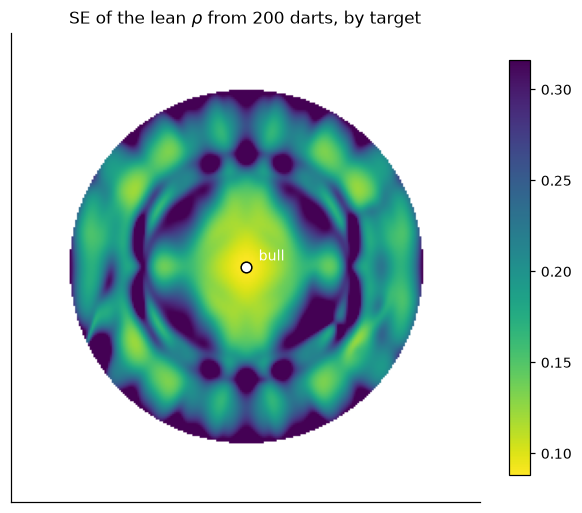

In [9]:
cand = candidate_targets(PX, point_stride=2)
I_pts = information_at_points(maps, cand)
v_rho, v_sig = c_criterion(I_pts, c_rho), c_criterion(I_pts, c_sig)
j_rho, j_sig = int(np.argmin(v_rho)), int(np.argmin(v_sig))

def radius(p):
    return float(np.hypot(*((np.asarray(p) - CENTRE) * MM)))

print(f'best target for the LEAN  : {aim_description(cand[j_rho], PX):>8s} '
      f'at r = {radius(cand[j_rho]):5.1f} mm   SE(rho) = {np.sqrt(v_rho[j_rho]/N_REF):.3f}')
print(f'best target for the SPREAD: {aim_description(cand[j_sig], PX):>8s} '
      f'at r = {radius(cand[j_sig]):5.1f} mm   SE(sigma) = {np.sqrt(v_sig[j_sig]/N_REF):.3f}')

se_rho_map = np.full((PX, PX), np.nan)
rad = np.hypot(*np.meshgrid(np.arange(PX) - CENTRE, np.arange(PX) - CENTRE, indexing='ij'))
inside = rad <= 170 / MM
se_rho_map[inside] = np.sqrt(c_criterion(maps['info'][inside], c_rho) / N_REF)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(se_rho_map, origin='lower', cmap='viridis_r',
               vmax=np.nanpercentile(se_rho_map, 90))
ax.plot(CENTRE, CENTRE, 'o', ms=7, color='white', mec='black')
ax.annotate('bull', (CENTRE, CENTRE), textcoords='offset points', xytext=(8, 4),
            color='white', fontsize=9)
ax.set_title(f'SE of the lean $\\rho$ from {N_REF} darts, by target')
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

*(learnability interpretation filled in from the output)*

,fitted rho,truth
drill target,,
bull,0.392,0.471
T20,0.439,0.471


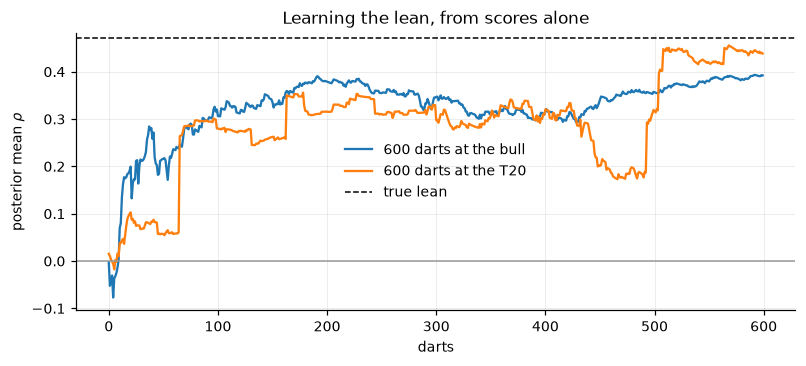

In [10]:
# and empirically, with the particle filter carrying the tilt
TRUE_LEARN = rotated_sigma(MAJOR, MINOR, 45.0)
rows = []
for target_name, target in [('bull', np.array([0.0, 0.0])),
                            ('T20', np.array([0.0, 103.0]))]:
    pf = ParticleThrowPosterior(600, band='league', tilt=True, board=BOARD,
                                checkouts=CHECKOUTS, rng=np.random.default_rng(3))
    L = np.linalg.cholesky(TRUE_LEARN)
    rng = np.random.default_rng(11)
    trace = []
    for _ in range(600):
        land = target + L @ rng.standard_normal(2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        pf.update(target, v, pixel=False)
        trace.append(pf.mean_rho())
    rows.append({'drill target': target_name, 'fitted rho': pf.mean_rho(),
                 'truth': correlation(TRUE_LEARN), 'trace': np.array(trace)})

fig, ax = plt.subplots(figsize=(7.4, 3.4))
for r in rows:
    ax.plot(r['trace'], lw=1.5, label=f"600 darts at the {r['drill target']}")
ax.axhline(correlation(TRUE_LEARN), color='k', ls='--', lw=1, label='true lean')
ax.axhline(0.0, color='#999', lw=1)
ax.set_xlabel('darts'); ax.set_ylabel(r'posterior mean $\rho$')
ax.set_title('Learning the lean, from scores alone')
ax.legend()
fig.tight_layout()

pd.DataFrame([{k: v for k, v in r.items() if k != 'trace'} for r in rows]
             ).set_index('drill target').round(3)

*(empirical interpretation filled in from the output)*

## Verdict

*(filled in from the outputs above)*